# Community Structure

We begin to explore the question of whether our model supports *community structure* under certain parameters. Here we measure community structure in a very simple way in terms of the spectral gap of the random-walk normalized graph Laplacian. If $L$ is the Laplacian and $\lambda_1,\ldots,\lambda_n$ are its eigenvalues in increasing order, we define the metric 

$$
\mu = j\frac{\lambda_2}{\sum_{i = 3}^{j+3} \lambda_i}. 
$$

This metric compares the size of $\lambda_2$ to the mean size of the next $j$ eigenvalues. Smaller values indicate a larger spectral gap which may in turn indicate community structure. In this notebook we consider the behavior of this metric as the parameter $\eta$ varies, but varying $\gamma$ and $\beta$ would likely also be of interest. 

*Analysis of this phenomenon would be of extremely interest and could potentially form the basis for its own paper. There are relatively few models that display emergent community structure, so this one could be *extremely* interesting.* 

In [1]:
import importlib 
m = importlib.import_module(".model", "src")
from matplotlib import pyplot as plt
import numpy as np
import xgi
import pandas as pd
import seaborn as sns

ModuleNotFoundError: No module named 'xgi'

# Batch Experiment

In [2]:
ETA = np.linspace(0.0, 1, 21)
gamma = 0.1
beta = 0.5
force_one_node = True

timesteps = int(1e3)

DF = pd.DataFrame()

for rep in range(50):
    for eta in ETA: 
        H = m.GrowingHypergraph()
        H.add_edge((0, 1, 2))
        H.add_edge((3, 4, 5))

        for _ in range(timesteps):
            H.sample_edge(eta, gamma, beta, force_one_node = force_one_node)
            
        L = H.rw_laplacian(sparse = True, weighted = True)
        evals, evecs = np.linalg.eig(L)
        evals = np.real(np.sort(evals))
        
        df = pd.DataFrame({
            "eta" : [eta], 
            "mu" : [evals[1] / (evals[2:7]).mean()]
        })
        DF = pd.concat([DF, df])

KeyboardInterrupt: 

<Axes: xlabel='eta', ylabel='mu'>

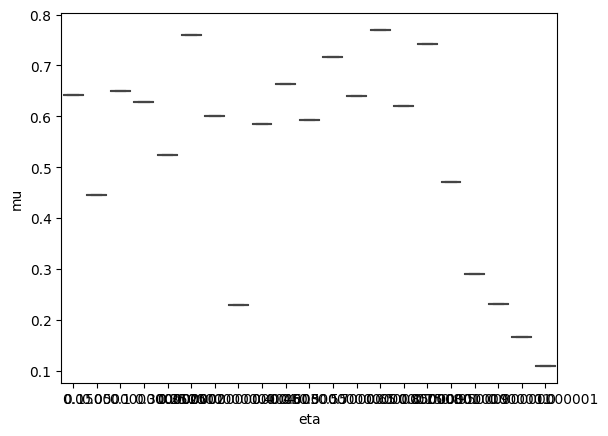

In [ ]:
sns.boxplot(DF, x = "eta", y = "mu")

In [64]:
timesteps = int(1e3)

eta = 0.9
H = m.GrowingHypergraph()
H.add_edge((0, 1, 2))
H.add_edge((3, 4, 5))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, force_one_node = force_one_node)
    
L = H.rw_laplacian(sparse = True, weighted = True)
evals, evecs = np.linalg.eig(L)
# evals = np.real(np.sort(evals))
[evals[1] / (evals[2:7]).mean()]

[0.3604327248160196]

In [65]:
(evecs[:,np.argsort(evals)][:,1] < 0).mean()

0.6161616161616161